In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import norm

In [3]:
from src.data_generators import generate_gaussian_mixture, generate_garch11
from src.r_bp import R_BP_density
from src.sampling import R_BP_sample
from src.rho_estimation import estimate_rho_grid
from src.rho_estimation_torch import estimate_rho_adam
from src.lag import lag_k_matrix

In [4]:
import importlib
import src.data_generators as data
import src.r_bp as rbp
import src.sampling as sampling
import src.rho_estimation as rho_
import src.lag as lag

importlib.reload(data)
importlib.reload(rbp)
importlib.reload(sampling)
importlib.reload(rho_)
importlib.reload(lag)

R_BP_sample = sampling.R_BP_sample
lag_k_matrix = lag.lag_k_matrix

### Gaussian mixture data

In [38]:
x = generate_gaussian_mixture(n=300, seed=123)

x_grid = np.linspace(-7, 7, 500)

### intial distribution

In [29]:
kde = gaussian_kde(x)

p0_grid = kde(x_grid)

dx = x_grid[1] - x_grid[0]

P0_grid = np.cumsum(p0_grid) * dx
P0_grid = P0_grid / P0_grid[-1]

def P0_inv(u):
    return np.interp(u, P0_grid, x_grid)

true_density = (0.5 * norm.pdf(x_grid, loc=-2.0, scale=0.5) + 0.5 * norm.pdf(x_grid, loc=2.0, scale=1.0))

### $\rho = 0.65$

In [30]:
rho_fixed = 0.65

p_fixed_mix, P_fixed_mix = R_BP_density(x=x, x_grid=x_grid, rho=rho_fixed, p0_grid=p0_grid, P0_grid=P0_grid)

samples_fixed_mix = R_BP_sample(x=x, x_grid=x_grid, rho=rho_fixed, n=500, P0_grid=P0_grid, P0_inv=P0_inv, seed=1)

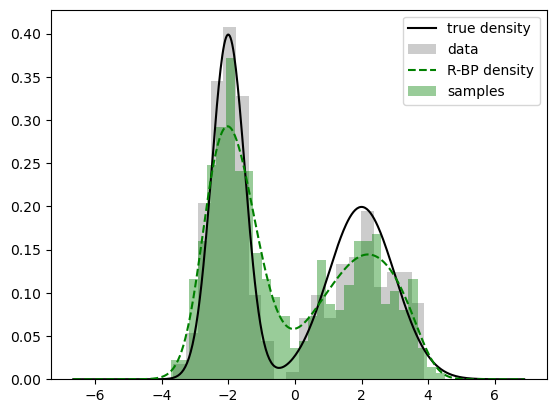

In [31]:
plt.plot(x_grid, true_density, color="black", label="true density")
plt.hist(x, bins=20, density=True, alpha=0.4, color="gray", label="data")
plt.plot(x_grid, p_fixed_mix, color="green" ,linestyle="--", label="R-BP density")
plt.hist(samples_fixed_mix, bins=30, density=True, alpha=0.4, color="green", label="samples")
plt.legend()
plt.show()

### $\rho$ estiated by grid search

In [32]:
rho_grid = np.linspace(0.05, 0.95, 50)

best_rho_grid, log_lik_list = estimate_rho_grid(x=x, x_grid=x_grid, p0_grid=p0_grid, P0_grid=P0_grid, rho_grid=rho_grid
)

print("best rho:", best_rho_grid)

best rho: 0.95


In [33]:
rho_best = best_rho_grid

p_best_rho_grid, P_best_rho_grid = R_BP_density(x=x, x_grid=x_grid,rho=rho_best, p0_grid=p0_grid, P0_grid=P0_grid)

samples_best_rho = R_BP_sample(x=x, x_grid=x_grid, rho=rho_best, n=500, P0_grid=P0_grid, P0_inv=P0_inv, seed=1)

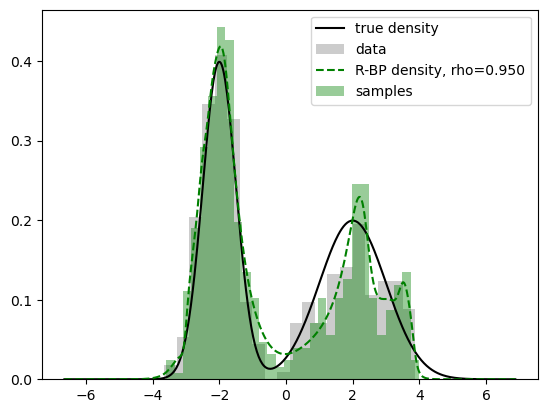

In [34]:
plt.plot(x_grid, true_density, color="black", label="true density")
plt.hist(x, bins=20, density=True, alpha=0.4, color="gray", label="data")
plt.plot(x_grid, p_best_rho_grid, color="green", linestyle="--", label=f"R-BP density, rho={rho_best:.3f}")
plt.hist(samples_best_rho, bins=30, density=True, alpha=0.4, color="green", label="samples")
plt.legend()
plt.show()

### $\rho$ estiated by ADAM

In [35]:
rho_adam, rho_path_adam, loss_path_adam = estimate_rho_adam(x=x, x_grid=x_grid, p0_grid=p0_grid, P0_grid=P0_grid, lr=0.05, n_iter=300)

print("best rho (ADAM):", rho_adam)

best rho (ADAM): 0.9546464492409698


In [36]:
rho_best_adam = rho_adam

p_best_rho_adam, P_best_rho_adam = R_BP_density(x=x, x_grid=x_grid, rho=rho_best_adam, p0_grid=p0_grid, P0_grid=P0_grid)

samples_best_rho_adam = R_BP_sample(x=x, x_grid=x_grid, rho=rho_best_adam, n=500, P0_grid=P0_grid, P0_inv=P0_inv, seed=1)

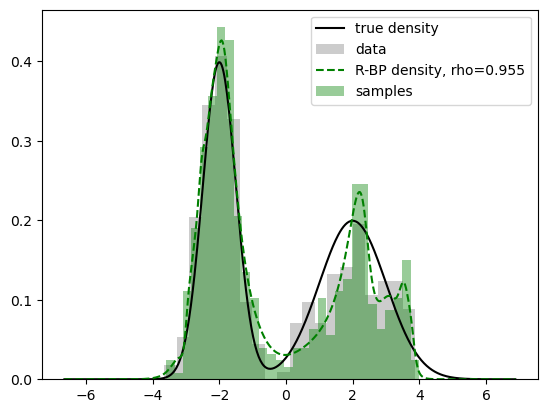

In [37]:
plt.plot(x_grid, true_density, color="black", label="true density")
plt.hist(x, bins=20, density=True, alpha=0.4, color="gray", label="data")
plt.plot(x_grid, p_best_rho_adam, color="green", linestyle="--", label=f"R-BP density, rho={rho_best_adam:.3f}")
plt.hist(samples_best_rho_adam, bins=30, density=True, alpha=0.4, color="green", label="samples")
plt.legend()
plt.show()